In [1]:
# ===== CELL 1: Top-N SKUs for forecasting =====
import pandas as pd, numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

ts = pd.read_csv("data/processed/timeseries_daily.csv", parse_dates=['InvoiceDate'])

# Pick top 20 SKUs by total revenue (Pareto: focus matters)
top_skus = (ts.groupby('StockCode')['revenue'].sum()
              .sort_values(ascending=False).head(20).index.tolist())
print(f"Top 20 SKUs cover {ts[ts['StockCode'].isin(top_skus)]['revenue'].sum() / ts['revenue'].sum():.1%} of total revenue")

Top 20 SKUs cover 79.8% of total revenue


In [2]:
# ===== CELL 2: Stationarity tests for top 5 SKUs =====
def stationarity_tests(series, sku):
    adf = adfuller(series.dropna())
    kp  = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"\n{sku}:")
    print(f"  ADF stat={adf[0]:.3f}, p-value={adf[1]:.4f}  → {'STATIONARY' if adf[1]<0.05 else 'NON-STATIONARY'}")
    print(f"  KPSS stat={kp[0]:.3f}, p-value={kp[1]:.4f}   → {'STATIONARY' if kp[1]>0.05 else 'NON-STATIONARY'}")
    return adf[1] < 0.05

results = {}
for sku in top_skus[:5]:
    s = (ts[ts['StockCode']==sku].set_index('InvoiceDate')['units_sold']
         .asfreq('D').fillna(0))
    results[sku] = stationarity_tests(s, sku)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14964\62023007.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14964\62023007.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14964\62023007.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(series.dropna(), regression='c', nlags='auto')
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14964\62023007.py:4: InterpolationWarning: The test statistic is outside of the 


SKU10105:
  ADF stat=-2.728, p-value=0.0694  → NON-STATIONARY
  KPSS stat=3.051, p-value=0.0100   → NON-STATIONARY

SKU10114:
  ADF stat=-2.511, p-value=0.1127  → NON-STATIONARY
  KPSS stat=3.181, p-value=0.0100   → NON-STATIONARY

SKU10100:
  ADF stat=-1.927, p-value=0.3195  → NON-STATIONARY
  KPSS stat=3.180, p-value=0.0100   → NON-STATIONARY

SKU10045:
  ADF stat=-2.169, p-value=0.2178  → NON-STATIONARY
  KPSS stat=2.944, p-value=0.0100   → NON-STATIONARY

SKU10108:
  ADF stat=-3.781, p-value=0.0031  → STATIONARY
  KPSS stat=3.971, p-value=0.0100   → NON-STATIONARY


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14964\62023007.py:4: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kp  = kpss(series.dropna(), regression='c', nlags='auto')


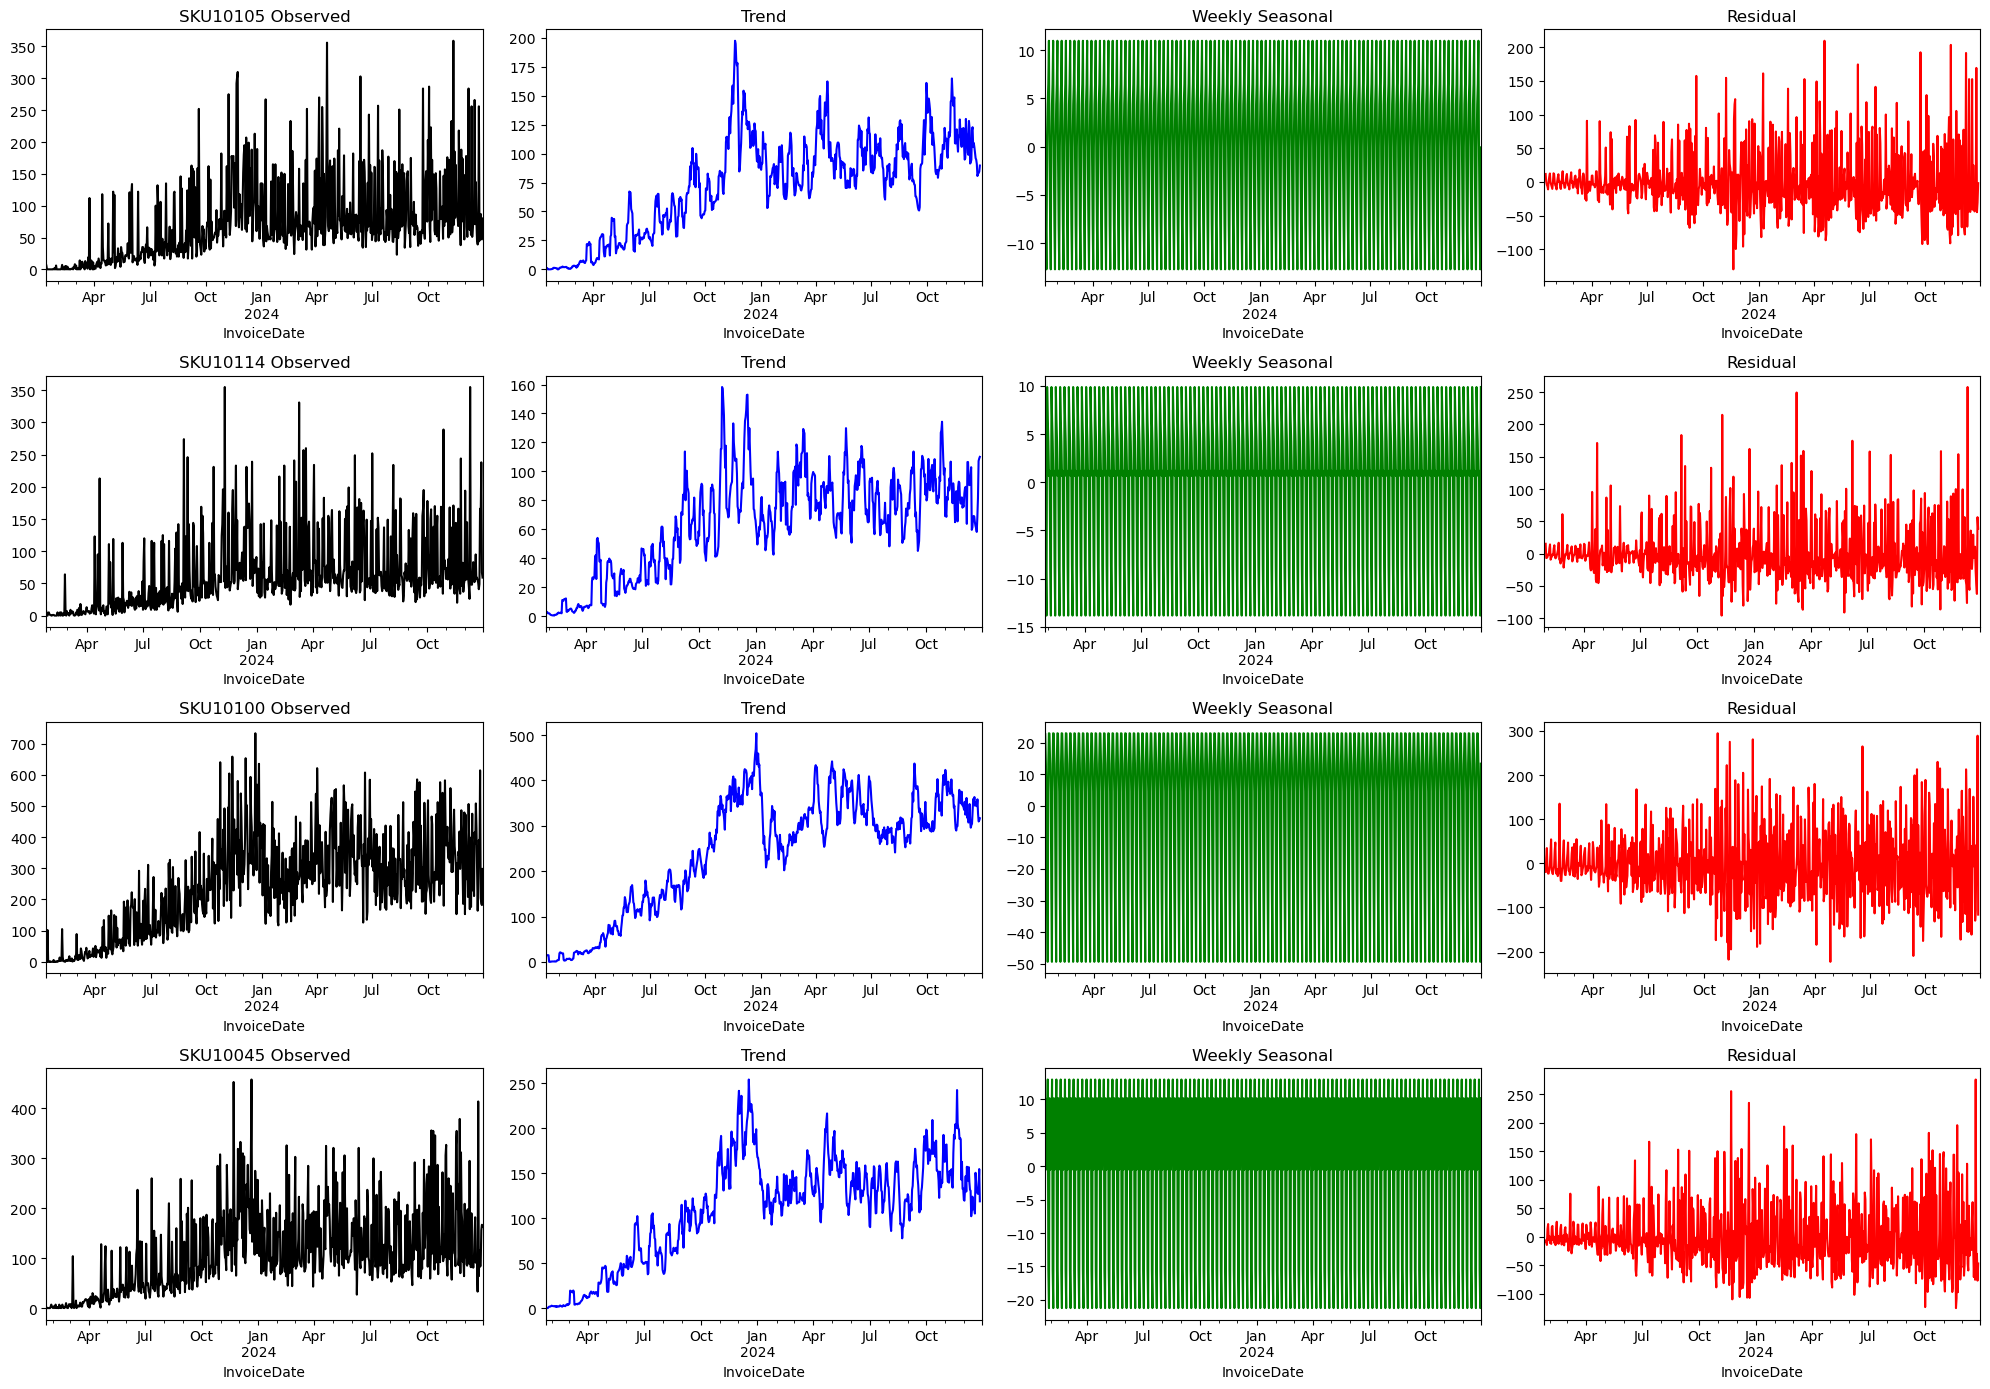

In [3]:
# ===== CELL 3: Seasonal decomposition (top 4 SKUs) =====
fig, axes = plt.subplots(4, 4, figsize=(20, 14))
for i, sku in enumerate(top_skus[:4]):
    s = (ts[ts['StockCode']==sku].set_index('InvoiceDate')['units_sold']
         .asfreq('D').fillna(0))
    decomp = seasonal_decompose(s, model='additive', period=7)  # weekly
    decomp.observed.plot(ax=axes[i,0], title=f'{sku} Observed', color='black')
    decomp.trend.plot(   ax=axes[i,1], title='Trend',           color='blue')
    decomp.seasonal.plot(ax=axes[i,2], title='Weekly Seasonal', color='green')
    decomp.resid.plot(   ax=axes[i,3], title='Residual',        color='red')

plt.tight_layout(); plt.savefig('reports/day4_decomposition.png', dpi=120); plt.show()


